# Import tensorflow

In [3]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.13.0+cu126
True
NVIDIA GeForce RTX 4070 SUPER


# Setup GPU as device

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# Load dataset

In [9]:
from torchvision import datasets
from torchvision.transforms import ToTensor

train_data = datasets.MNIST(
    root="data",
    train=True,
    transform=ToTensor(),
    download=True
)

test_data = datasets.MNIST(
    root="data",
    train=False,
    transform=ToTensor()
)

100%|██████████| 9.91M/9.91M [00:04<00:00, 2.43MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 212kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.16MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.27MB/s]


In [26]:
print(f"Train dataset size: {len(train_data)}\nTest dataset size: {len(test_data)}")
print(f"Data shape: {train_data[0][0].shape} and first label is {train_data[0][1]}")

Train dataset size: 60000
Test dataset size: 10000
Data shape: torch.Size([1, 28, 28]) and first label is 5


# Vizualize a few examples

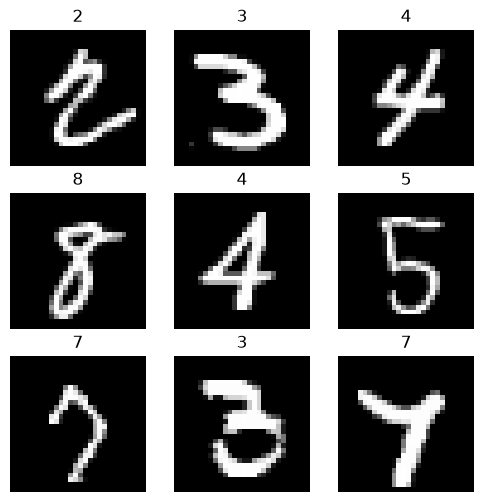

In [29]:
import matplotlib.pyplot as plt

figure = plt.figure(figsize=(6, 6))

cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_data), size=(1,)).item()
    img, label = train_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

# Create dataloader